In [15]:
import pyransac3d as pyrsc
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt


In [7]:
data_path = "output/west_ref/pipe/test/"
el = "0.pcd"

inp = o3d.io.read_point_cloud(data_path + el)
points = np.asarray(inp.points)

In [24]:
points = points/10000

In [26]:
print(points)

[[-2.71561504  1.24270986  5.05252813]
 [-2.25361953  1.2453667   5.05586797]
 [-2.26717988  1.24197422  5.05441758]
 ...
 [-2.08227891  1.24214336  5.05207305]
 [-2.08227891  1.24730068  5.05192266]
 [-2.56187422  1.24438369  5.05595898]]


In [27]:
clnd = pyrsc.Cylinder()
center,axis, radius, inliers = clnd.fit(points, thresh=0.4, maxIteration=10000)


/home/haritha/miniconda3/envs/cdbb/lib/python3.9/site-packages/pyransac3d/cylinder.py:78: RuntimeWarning: divide by zero encountered in double_scalars
  mb = (P_rot[2, 1] - P_rot[1, 1]) / (P_rot[2, 0] - P_rot[1, 0])
/home/haritha/miniconda3/envs/cdbb/lib/python3.9/site-packages/pyransac3d/cylinder.py:77: RuntimeWarning: divide by zero encountered in double_scalars
  ma = (P_rot[1, 1] - P_rot[0, 1]) / (P_rot[1, 0] - P_rot[0, 0])
/home/haritha/miniconda3/envs/cdbb/lib/python3.9/site-packages/pyransac3d/cylinder.py:86: RuntimeWarning: invalid value encountered in double_scalars
  ma * mb * (P_rot[0, 1] - P_rot[2, 1])
/home/haritha/miniconda3/envs/cdbb/lib/python3.9/site-packages/pyransac3d/cylinder.py:65: RuntimeWarning: invalid value encountered in true_divide
  vecC = vecC / np.linalg.norm(vecC)
/home/haritha/miniconda3/envs/cdbb/lib/python3.9/site-packages/pyransac3d/cylinder.py:61: RuntimeWarning: invalid value encountered in true_divide
  vecB_norm = vecB / np.linalg.norm(vecB)
/home

In [30]:
print(center,axis, radius)

[-2.30477221  7.59882437 10.80220601] [ 0.01025063  0.81888855 -0.57386102] 8.572046275429996


In [28]:
X, Y, Z = points[:,0], points[:,1], points[:,2]
inliers_X, inliers_Y, inliers_Z = X[inliers], Y[inliers], Z[inliers]

/tmp/ipykernel_267187/2530723298.py:2: MatplotlibDeprecationWarning: 
The set_window_title function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use manager.set_window_title or GUI-specific methods instead.
  fig.canvas.set_window_title('')


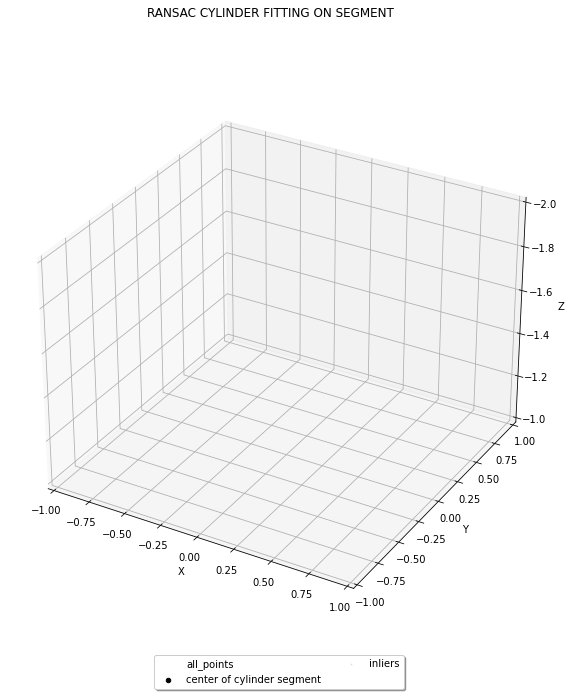

In [29]:

fig = plt.figure(figsize=(10, 10))
fig.canvas.set_window_title('')
fig.suptitle('RANSAC CYLINDER FITTING ON SEGMENT')
ax = plt.axes(projection="3d")
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.xlim([-1, 1])
plt.ylim([-1, 1])
ax.set_zlim(-1, -2)
# PLOT ALL POINTS
ax.scatter(X, Y, Z, s=1, alpha = 0.01, c='grey', label='all_points')
# PLOT CENTER OF CYLINDER (pyransac)
ax.scatter(center[0], center[1], center[2], s=20, c='black', label='center of cylinder segment')
# PLOT INLIERS CYLINDER (pyransac)
ax.scatter(inliers_X, inliers_Y, inliers_Z, s=1, alpha= 0.25, c='orange', label='inliers')
# PLOT CYLINDER SEGMENT
def data_for_cylinder_along_z(center_x, center_y, center_z, radius, height_z):
    z = np.linspace(center_z, center_z + height_z, 50)
    theta = np.linspace(0, 2 * np.pi, 50)
    theta_grid, z_grid = np.meshgrid(theta, z)
    x_grid = radius * np.cos(theta_grid) + center_x
    y_grid = radius * np.sin(theta_grid) + center_y
    return x_grid, y_grid, z_grid
Xc, Yc, Zc = data_for_cylinder_along_z(center[0], center[1], center[2], radius, 0.62)  # TODO calculate heigth
ax.plot_surface(Xc, Yc, Zc, color='red', alpha=0.75)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), shadow=True, ncol=2)
plt.show()
plt.close(fig)